In [ ]:
# ============================================================
# CELL 1: IMPORT
# ============================================================
import os, json, pickle, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    accuracy_score, roc_auc_score,
    precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from scipy.stats import skew as scipy_skew
from scipy.signal import welch
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__} | GPU: {gpus}')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: ON')
    except Exception as e:
        print(f'Mixed precision N/A: {e}')
else:
    print('⚠️  Không có GPU — Runtime > Change runtime type > GPU')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Import xong.')

TensorFlow : 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: ON
✅ Import xong.


In [ ]:
# ============================================================
# CELL 2: CONFIG
# ============================================================
IN_COLAB = 'google.colab' in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

DATA_ROOTS = [
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/An'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hao'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hieu'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Kien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Quan'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Tien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Cong'),
]
OUTPUT_DIR = Path('/content/drive/MyDrive/data_pbl5/models_7_pers_feature')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE        = 50
WINDOW_SIZE        = 100
OVERLAP_RATIO      = 0.5
NUM_CHANNELS       = 6
CLASS_NAMES        = ['Normal', 'Fall']
N_HOT_WINDOWS      = 5
EXCLUDE_SUBFOLDERS = ['LonXon']   # Bỏ subfolder này khỏi tất cả subjects

print('✅ Config:')
print(f'  Window          : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.1f}s @ {SAMPLE_RATE}Hz')
print(f'  N_HOT_WINDOWS   : {N_HOT_WINDOWS}')
print(f'  Exclude folders : {EXCLUDE_SUBFOLDERS}')
print(f'  Output          : {OUTPUT_DIR}')

Mounted at /content/drive
✅ Config:
  Window          : 100 samples = 2.0s @ 50Hz
  N_HOT_WINDOWS   : 5
  Exclude folders : ['LonXon']
  Output          : /content/drive/MyDrive/data_pbl5/models_7_pers_feature


In [ ]:
# ============================================================
# CELL 3: LOAD DATA
# ============================================================
def load_session(session_dir):
    session_dir = Path(session_dir)
    accel_path  = session_dir / 'accel.csv'
    gyro_path   = session_dir / 'gyro.csv'

    if not (accel_path.exists() and gyro_path.exists()):
        return None, None

    folder_name = session_dir.name
    label = None
    if folder_name.startswith('label'):
        try:
            label = int(folder_name[5])
        except (ValueError, IndexError):
            label = None
    if label is None:
        label_path = session_dir / 'label.txt'
        if label_path.exists():
            try:
                label = int(label_path.read_text().strip())
            except Exception:
                return None, None
        else:
            return None, None

    try:
        accel = pd.read_csv(accel_path)
        gyro  = pd.read_csv(gyro_path)
    except Exception:
        return None, None

    if accel.empty or gyro.empty:
        return None, None
    if accel.shape[1] != 4 or gyro.shape[1] != 4:
        return None, None

    accel.columns = ['time', 'ax', 'ay', 'az']
    gyro.columns  = ['time', 'gx', 'gy', 'gz']

    min_len = min(len(accel), len(gyro))
    df = pd.concat([
        accel[['ax', 'ay', 'az']].iloc[:min_len].reset_index(drop=True),
        gyro [['gx', 'gy', 'gz']].iloc[:min_len].reset_index(drop=True),
    ], axis=1)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if len(df) < WINDOW_SIZE // 2:
        return None, None

    return df, label


def load_all_sessions(data_roots):
    sessions = []
    stats = {name: 0 for name in CLASS_NAMES}
    stats['errors'] = stats['skipped'] = 0

    def find_session_dirs(base_dir):
        result = []
        if not base_dir.exists():
            return result
        for entry in sorted(base_dir.iterdir()):
            if entry.is_dir():
                if (entry / 'accel.csv').exists():
                    result.append(entry)
                else:
                    result.extend(find_session_dirs(entry))
        return result

    for root in data_roots:
        root        = Path(root)
        person_name = root.name
        print(f'\n📁 {root}  [subject={person_name}]')

        for class_name in CLASS_NAMES:
            class_dir = root / class_name
            if not class_dir.exists():
                print(f'   ⚠️  Thiếu thư mục: {class_dir}')
                continue

            sess_dirs = find_session_dirs(class_dir)

            # ── Filter EXCLUDE_SUBFOLDERS ─────────────────────
            before = len(sess_dirs)
            sess_dirs = [
                sd for sd in sess_dirs
                if not any(ex in sd.parts for ex in EXCLUDE_SUBFOLDERS)
            ]
            after = len(sess_dirs)
            if before != after:
                print(f'   🗑️  {class_name}: bỏ {before - after} sessions '
                      f'({EXCLUDE_SUBFOLDERS}) → còn {after}')

            print(f'   {class_name}: {len(sess_dirs)} sessions')

            subfolder_counts = {}
            for sd in sess_dirs:
                try:
                    subfolder = sd.relative_to(class_dir).parts[0]
                except Exception:
                    subfolder = '(root)'
                subfolder_counts[subfolder] = subfolder_counts.get(subfolder, 0) + 1
            for sf, cnt in sorted(subfolder_counts.items()):
                print(f'      └─ {sf}: {cnt}')

            expected_label = CLASS_NAMES.index(class_name)
            for sess_dir in sess_dirs:
                df, lbl = load_session(sess_dir)
                if df is None:
                    stats['errors'] += 1
                    continue
                if lbl != expected_label:
                    print(f'   ⚠️  Label mismatch: {sess_dir.name} '
                          f'(file={lbl}, expected={expected_label})')
                    stats['skipped'] += 1
                    continue
                stats[class_name] += 1
                sessions.append((df, lbl, person_name))

    print('\n' + '─' * 50)
    total = sum(stats[c] for c in CLASS_NAMES)
    print(f'📊 Tổng sessions hợp lệ: {total}')
    for c in CLASS_NAMES:
        print(f'   {c:7}: {stats[c]}')
    print(f'   Lỗi / mismatch: {stats["errors"]} / {stats["skipped"]}')

    if not sessions:
        raise ValueError('❌ Không có session nào.')
    found_labels = {lbl for _, lbl, _ in sessions}
    if len(found_labels) < 2:
        raise ValueError(f'❌ Chỉ có 1 class.')
    return sessions


all_sessions = load_all_sessions(DATA_ROOTS)
print(f'\n✅ Load xong: {len(all_sessions)} sessions.')


📁 /content/drive/MyDrive/data_pbl5/Self-Collected/An  [subject=An]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hao  [subject=Hao]
   Normal: 52 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 17
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hieu  [subject=Hieu]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 51 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 26

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Kien  [subject=Kien]
   Normal: 45 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 11
      └─ GoPhim: 10
      └─ LuotDienThoai: 9
   Fall: 36 sessions
      └─ NgaRaSau: 18
      └─ NgaRaTruoc: 18

📁 

In [ ]:
# ============================================================
# CELL 4: FEATURE EXTRACTION
# ============================================================
CHANNEL_NAMES = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
PER_CH_FEATS  = ['variance', 'std', 'mean', 'median',
                 'max', 'min', 'delta', 'psd', 'pse', 'skewness']
FEATURE_NAMES = (
    [f'{ch}_{f}' for ch in CHANNEL_NAMES for f in PER_CH_FEATS] +
    ['smv_skewness', 'smv_jerk_peak']
)


def extract_features(window: np.ndarray) -> np.ndarray:
    features = []
    dt  = 1.0 / SAMPLE_RATE
    acc = window[:, :3]
    smv = np.sqrt(np.sum(acc ** 2, axis=1))

    for ch_idx in range(6):
        ch = window[:, ch_idx]
        features.append(float(np.var(ch)))
        features.append(float(np.std(ch)))
        features.append(float(np.mean(ch)))
        features.append(float(np.median(ch)))
        features.append(float(np.max(ch)))
        features.append(float(np.min(ch)))
        features.append(float(np.max(ch) - np.min(ch)))

        freqs, psd = welch(ch, fs=SAMPLE_RATE, nperseg=min(32, len(ch)))
        psd_norm   = psd / (np.sum(psd) + 1e-8)
        features.append(float(np.mean(psd)))
        features.append(float(-np.sum(psd_norm * np.log2(psd_norm + 1e-8))))
        features.append(float(scipy_skew(ch)))

    features.append(float(scipy_skew(smv)))
    jerk = np.diff(smv) / dt
    features.append(float(np.max(np.abs(jerk))))

    feat_arr = np.array(features, dtype=np.float32)
    feat_arr = np.nan_to_num(feat_arr, nan=0.0, posinf=0.0, neginf=0.0)
    return feat_arr


# Verify
_f = extract_features(np.random.randn(100, 6).astype(np.float32))
assert len(_f) == len(FEATURE_NAMES), f'Mismatch: {len(_f)} vs {len(FEATURE_NAMES)}'
print(f'✅ Feature vector: {len(_f)} features')

✅ Feature vector: 62 features


In [ ]:
# ============================================================
# CELL 5: BUILD DATASET (sliding window + N_HOT_WINDOWS)
# ============================================================
def build_feature_dataset(sessions, window_size, overlap_ratio, n_hot_windows):
    X_list, y_list, p_list = [], [], []
    step       = max(int(window_size * (1 - overlap_ratio)), 1)
    fall_total = 0
    fall_kept  = 0
    normal_total = 0

    for df, label, person in sessions:
        arr = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].values.astype(np.float32)
        windows = [
            arr[start:start + window_size]
            for start in range(0, len(arr) - window_size + 1, step)
        ]

        if label == 1:  # Fall → chỉ giữ n_hot_windows đầu
            fall_total += len(windows)
            windows = windows[:n_hot_windows]
            fall_kept += len(windows)
        else:
            normal_total += len(windows)

        for w in windows:
            X_list.append(extract_features(w))
            y_list.append(label)
            p_list.append(person)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    p = np.array(p_list)

    print('── Dataset Summary ─────────────────────────────────────')
    print(f'Normal windows (giữ hết)   : {normal_total}')
    print(f'Fall windows trước khi trim: {fall_total}')
    print(f'Fall windows sau khi trim  : {fall_kept} '
          f'({fall_kept/fall_total*100:.1f}%)')
    print(f'Đã loại bỏ {fall_total - fall_kept} window "nằm yên sau ngã"')
    print(f'X shape  : {X.shape}')
    print(f'Normal   : {int(np.sum(y == 0))} windows')
    print(f'Fall     : {int(np.sum(y == 1))} windows')
    ratio = np.sum(y == 0) / max(np.sum(y == 1), 1)
    print(f'Tỷ lệ N/F: {ratio:.2f}x '
          f'{"✅" if ratio < 3 else "(lệch, class_weight sẽ bù)"}')
    return X, y, p


# ── Gọi lại với n_hot_windows ────────────────────────────────
X_raw, y_raw, persons = build_feature_dataset(
    all_sessions, WINDOW_SIZE, OVERLAP_RATIO, N_HOT_WINDOWS
)


── Dataset Summary ─────────────────────────────────────
Normal windows (giữ hết)   : 1509
Fall windows trước khi trim: 2040
Fall windows sau khi trim  : 1712 (83.9%)
Đã loại bỏ 328 window "nằm yên sau ngã"
X shape  : (3221, 62)
Normal   : 1509 windows
Fall     : 1712 windows
Tỷ lệ N/F: 0.88x ✅


In [ ]:
unique_persons = sorted(set(persons))
print(f'\n✅ Subjects: {unique_persons}')


✅ Subjects: [np.str_('An'), np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]


In [ ]:
# Đầu Cell 6 — reset trước khi chạy
# Thêm 'proba' vào results dict ở đầu Cell 6
def optimal_threshold(y_true, y_proba):
    prec, rec, thrs = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])  # bỏ phần tử cuối (threshold=1.0)
    return float(thrs[best_idx]) if len(thrs) > 0 else 0.5
results = {
    'RF': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': [],
           'tn': [], 'fp': [], 'fn': [], 'tp': [],
           'threshold': [], 'subject': [], 'proba': []},  # ← thêm proba
    'GB': {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': [],
           'tn': [], 'fp': [], 'fn': [], 'tp': [],
           'threshold': [], 'subject': [], 'proba': []},  # ← thêm proba
}

# Và trong loop, sau dòng r['threshold'].append(thr):
  # ← thêm dòng này
for fold, test_person in enumerate(unique_persons):
    train_subjs = [p for p in unique_persons if p != test_person]
    print(f'{"─"*55}')
    print(f'Fold {fold+1}: TEST={test_person} | TRAIN={train_subjs}')

    test_mask  = (persons == test_person)
    train_mask = ~test_mask

    X_train_all, y_train_all = X_raw[train_mask], y_raw[train_mask]
    X_test,      y_test      = X_raw[test_mask],  y_raw[test_mask]

    if np.sum(y_test==1) == 0 or np.sum(y_test==0) == 0:
        print('⚠️  Thiếu class → bỏ qua')
        continue

    # ── Tách val từ train để tìm threshold ──────────────────
    # KHÔNG dùng test set vào bất kỳ bước nào trước evaluate
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.15,
        random_state=SEED + fold,
        stratify=y_train_all
    )
    print(f'Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)} '
          f'(N={int(np.sum(y_test==0))}, F={int(np.sum(y_test==1))})')

    # Scale fit trên train, transform val và test
    scaler_fold = StandardScaler()
    X_tr_s  = scaler_fold.fit_transform(X_tr)
    X_val_s = scaler_fold.transform(X_val)
    X_te_s  = scaler_fold.transform(X_test)

    for model_name, model in [
        ('RF', RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight='balanced', random_state=SEED, n_jobs=-1)),
        ('GB', GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=2, random_state=SEED)),
    ]:
        # Train trên train set
        model.fit(X_tr_s, y_tr)

        # Tìm threshold trên VAL — không đụng test
        val_proba = model.predict_proba(X_val_s)[:, 1]
        thr       = optimal_threshold(y_val, val_proba)  # ← val, không phải test

        # Evaluate trên TEST
        te_proba = model.predict_proba(X_te_s)[:, 1]
        pred     = (te_proba >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
        r = results[model_name]
        r['acc'].append(accuracy_score(y_test, pred))
        r['prec'].append(precision_score(y_test, pred, zero_division=0))
        r['rec'].append(recall_score(y_test, pred, zero_division=0))
        r['f1'].append(f1_score(y_test, pred, zero_division=0))
        r['auc'].append(roc_auc_score(y_test, te_proba))
        r['tn'].append(int(tn));  r['fp'].append(int(fp))
        r['fn'].append(int(fn));  r['tp'].append(int(tp))
        r['threshold'].append(thr)
        r['proba'].append(te_proba)
        r['subject'].append(test_person)

        print(f'   {model_name}: F1={r["f1"][-1]:.4f} | '
              f'Rec={r["rec"][-1]:.4f} | AUC={r["auc"][-1]:.4f} | '
              f'thr={thr:.3f}')
        print(f'        TN={tn} | FP={fp}(False Alarm) | '
              f'FN={fn}(Miss⚠️) | TP={tp}')

───────────────────────────────────────────────────────
Fold 1: TEST=An | TRAIN=[np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]
Train: 2396 | Val: 423 | Test: 402 (N=160, F=242)
   RF: F1=0.9874 | Rec=0.9752 | AUC=1.0000 | thr=0.554
        TN=160 | FP=0(False Alarm) | FN=6(Miss⚠️) | TP=236
   GB: F1=0.9938 | Rec=0.9876 | AUC=1.0000 | thr=0.422
        TN=160 | FP=0(False Alarm) | FN=3(Miss⚠️) | TP=239
───────────────────────────────────────────────────────
Fold 2: TEST=Cong | TRAIN=[np.str_('An'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]
Train: 2249 | Val: 398 | Test: 574 (N=274, F=300)
   RF: F1=0.9719 | Rec=0.9800 | AUC=0.9968 | thr=0.526
        TN=263 | FP=11(False Alarm) | FN=6(Miss⚠️) | TP=294
   GB: F1=0.9584 | Rec=0.9600 | AUC=0.9924 | thr=0.413
        TN=261 | FP=13(False Alarm) | FN=12(Miss⚠️) | TP=288
───────────────────────────────────────────────────────
Fold 3: TEST=Hao | TR

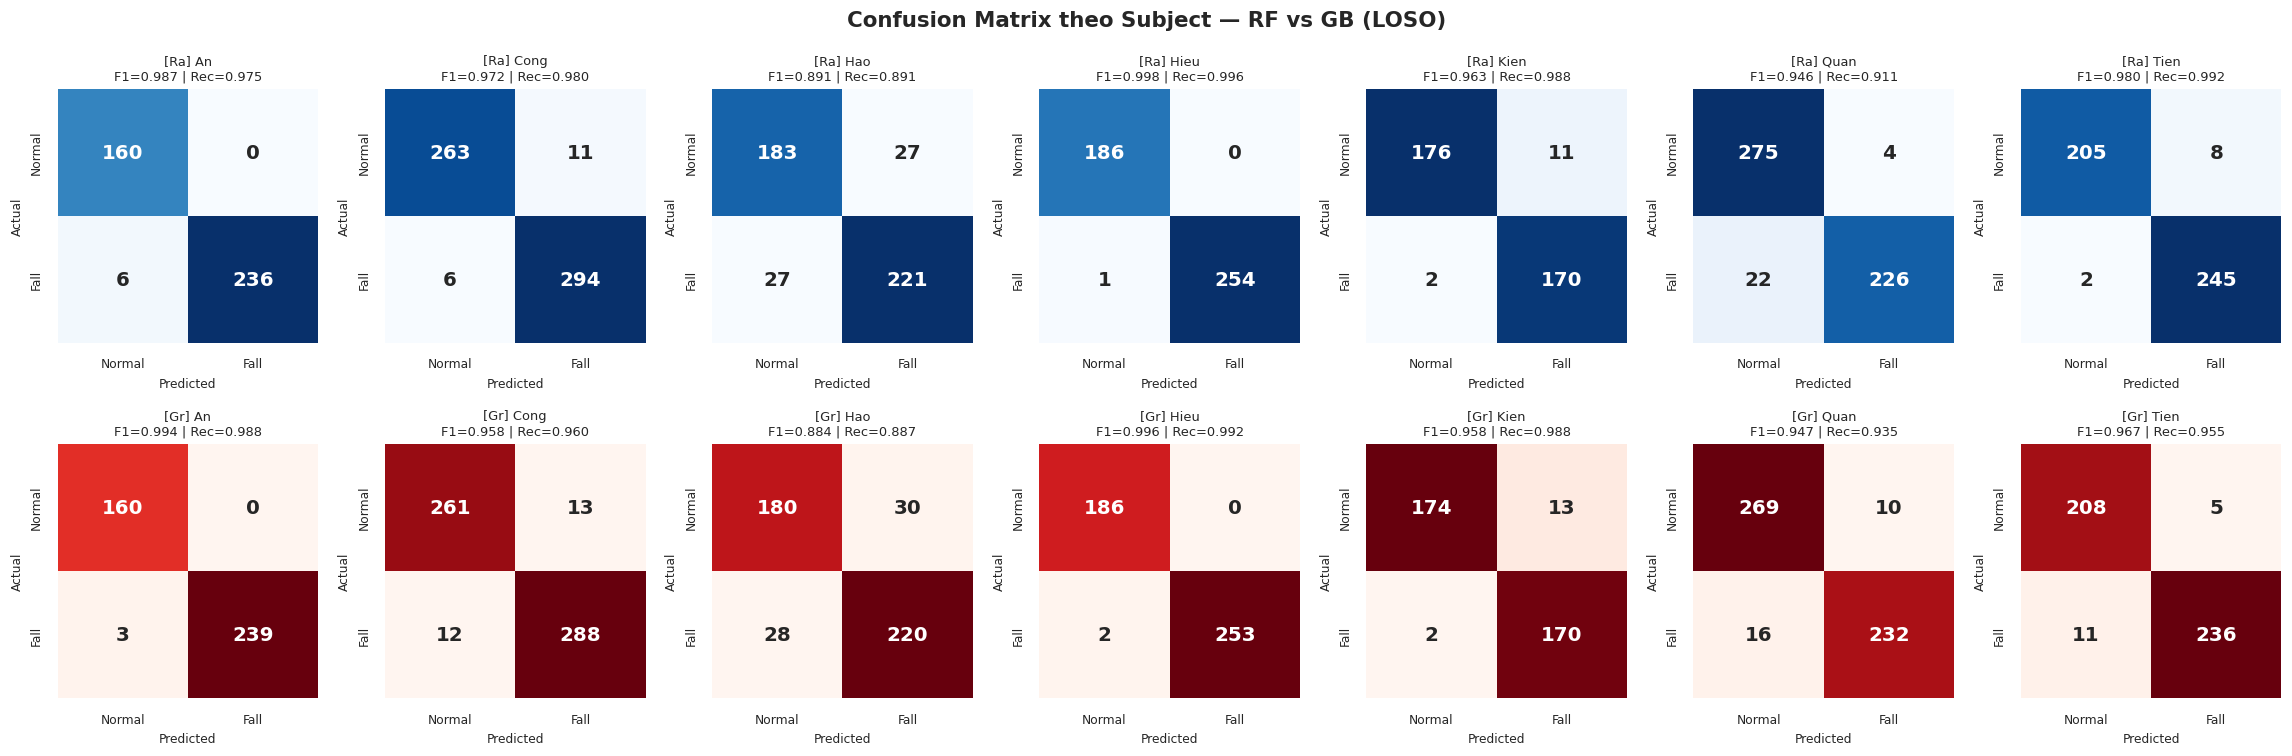

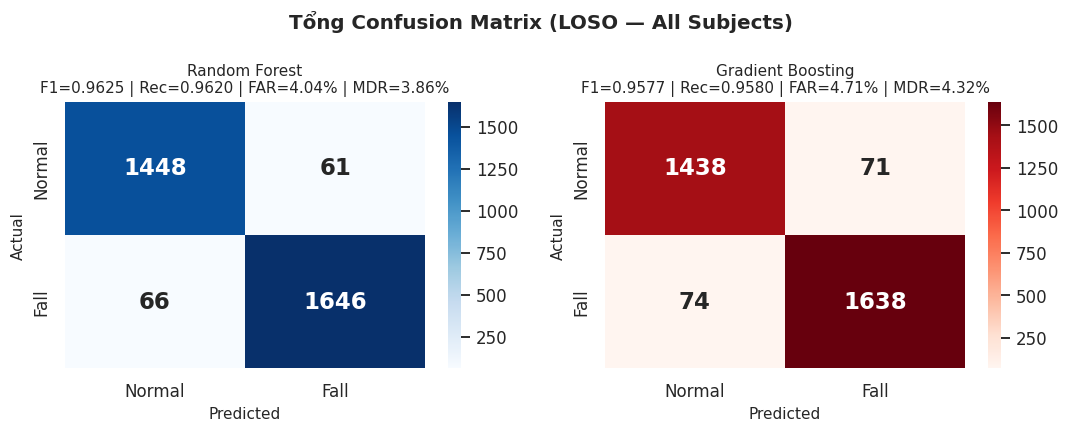

In [ ]:
# ============================================================
# CELL 8: CONFUSION MATRIX VISUALIZATION
# ============================================================
n_subjects = len(results['RF']['subject'])  # = 7

fig, axes = plt.subplots(2, n_subjects, figsize=(n_subjects * 3, 7))
fig.suptitle('Confusion Matrix theo Subject — RF vs GB (LOSO)',
             fontsize=14, fontweight='bold')

for row, model_name in enumerate(['RF', 'GB']):
    r     = results[model_name]
    label = 'Random Forest' if model_name == 'RF' else 'Gradient Boosting'

    for col, subj in enumerate(r['subject']):
        ax = axes[row][col]
        cm = np.array([
            [r['tn'][col], r['fp'][col]],
            [r['fn'][col], r['tp'][col]],
        ])

        sns.heatmap(
            cm, annot=True, fmt='d', ax=ax,
            cmap='Blues' if model_name == 'RF' else 'Reds',
            cbar=False,
            xticklabels=['Normal', 'Fall'],
            yticklabels=['Normal', 'Fall'],
            annot_kws={'size': 13, 'weight': 'bold'},
        )
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('Actual', fontsize=8)
        ax.set_title(f'[{label[:2]}] {subj}\n'
                     f'F1={r["f1"][col]:.3f} | Rec={r["rec"][col]:.3f}',
                     fontsize=8.5)
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_loso.png', dpi=150)
plt.show()

# ── Tổng confusion matrix ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Tổng Confusion Matrix (LOSO — All Subjects)',
             fontsize=13, fontweight='bold')

for ax, model_name in zip(axes, ['RF', 'GB']):
    r     = results[model_name]
    label = 'Random Forest' if model_name == 'RF' else 'Gradient Boosting'
    tn_t  = sum(r['tn']); fp_t = sum(r['fp'])
    fn_t  = sum(r['fn']); tp_t = sum(r['tp'])
    cm    = np.array([[tn_t, fp_t], [fn_t, tp_t]])

    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues' if model_name == 'RF' else 'Reds',
        cbar=True,
        xticklabels=['Normal', 'Fall'],
        yticklabels=['Normal', 'Fall'],
        annot_kws={'size': 15, 'weight': 'bold'},
    )
    far = fp_t / (fp_t + tn_t) * 100
    mdr = fn_t / (fn_t + tp_t) * 100
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.set_title(f'{label}\n'
                 f'F1={np.mean(r["f1"]):.4f} | '
                 f'Rec={np.mean(r["rec"]):.4f} | '
                 f'FAR={far:.2f}% | MDR={mdr:.2f}%',
                 fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_total.png', dpi=150)
plt.show()

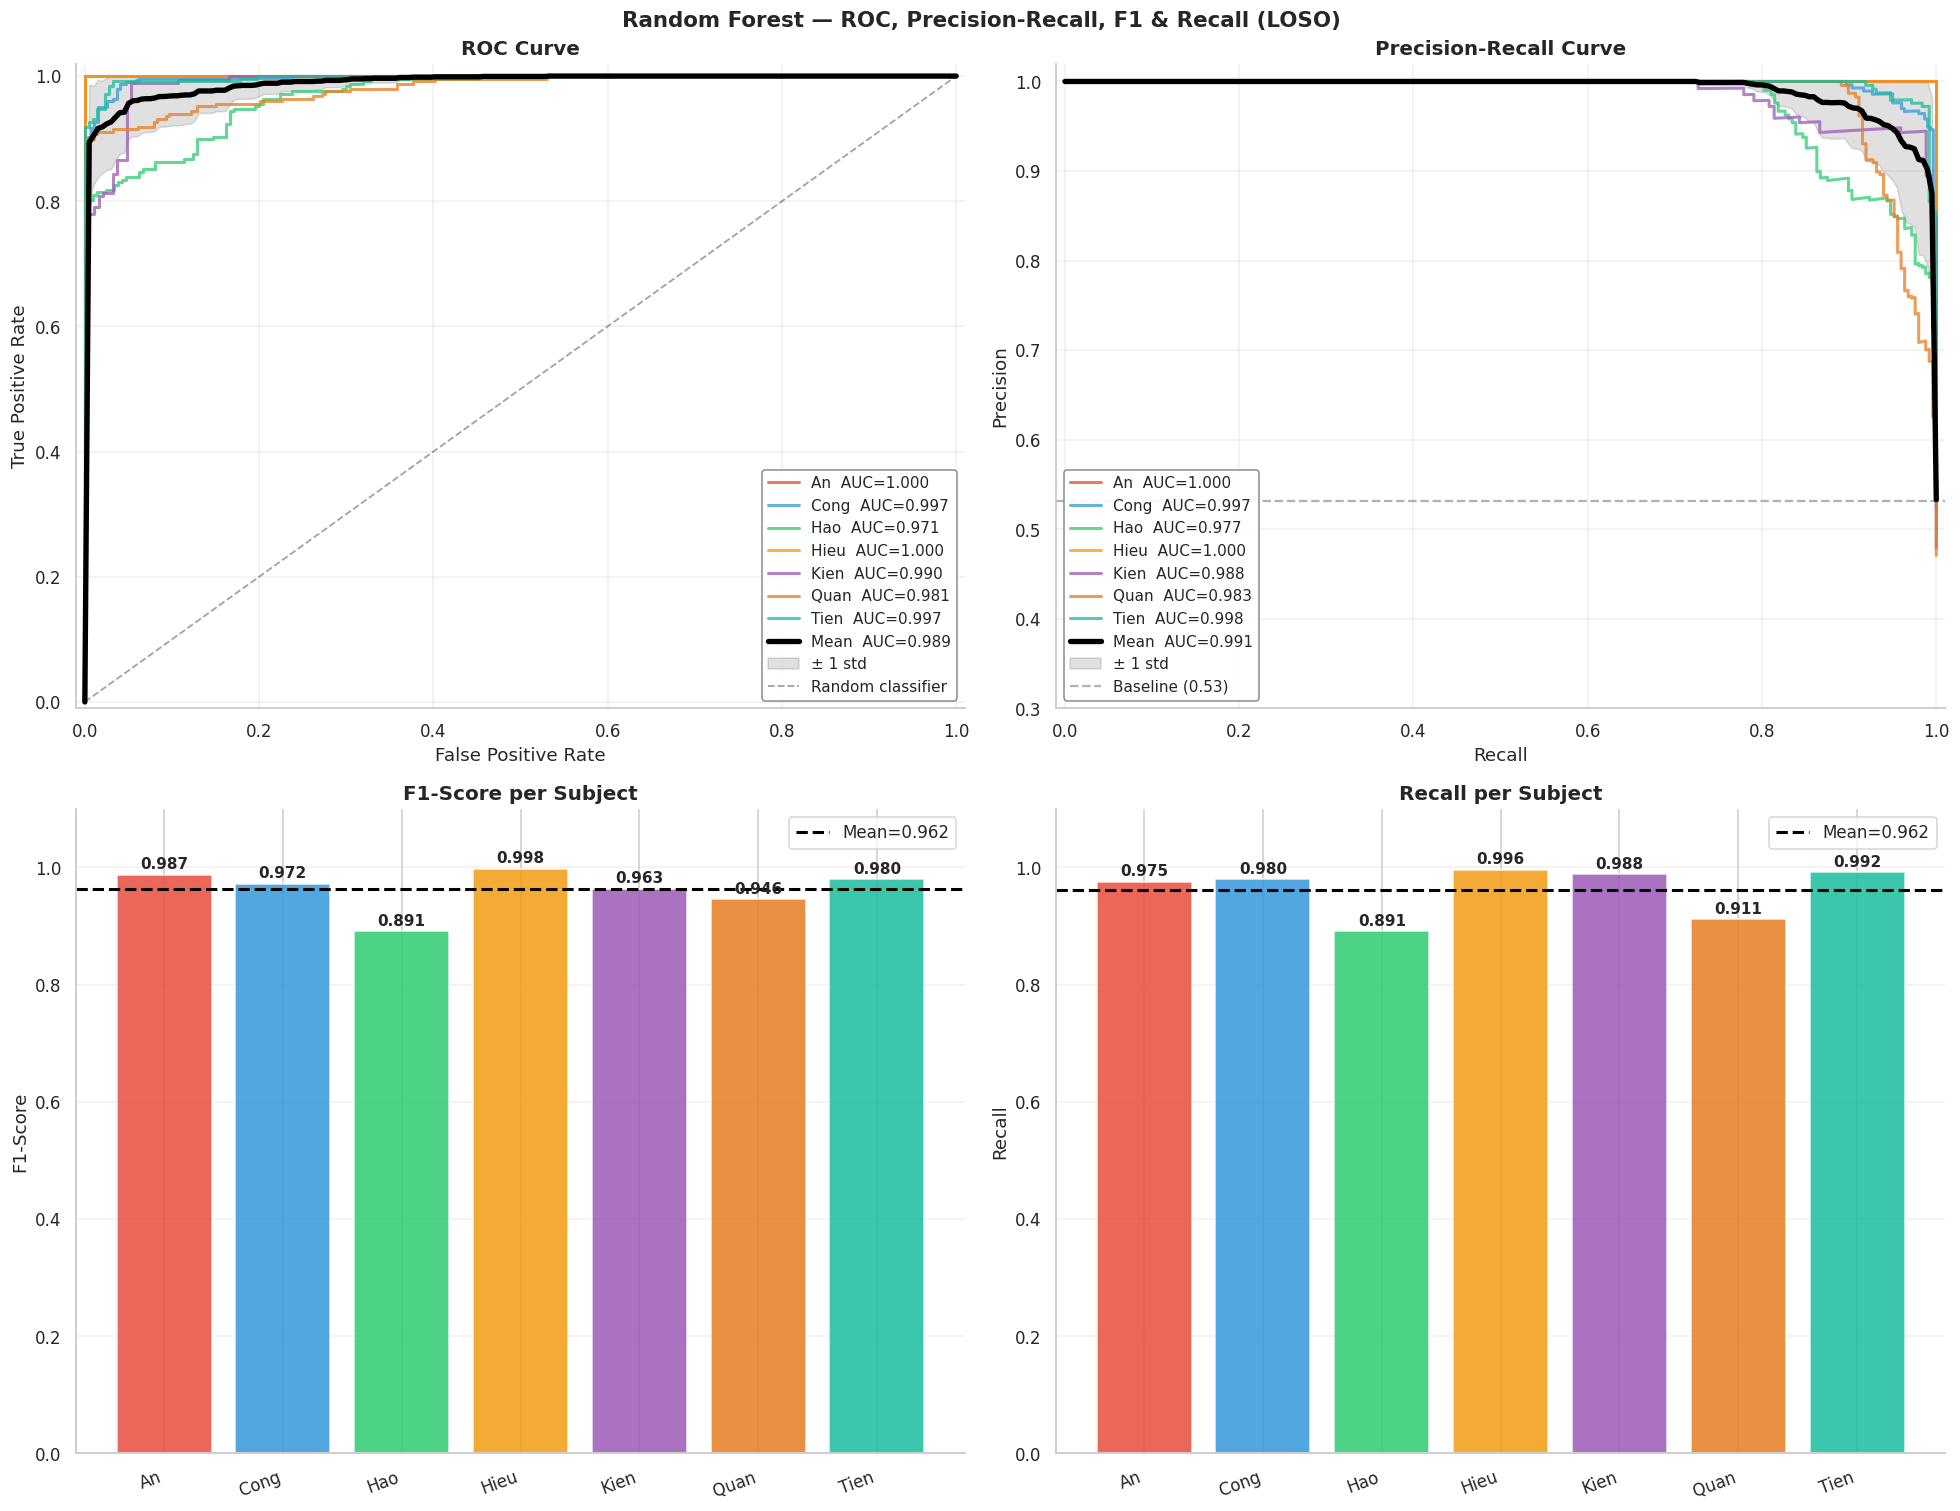

✅ Saved: curves_rf.png


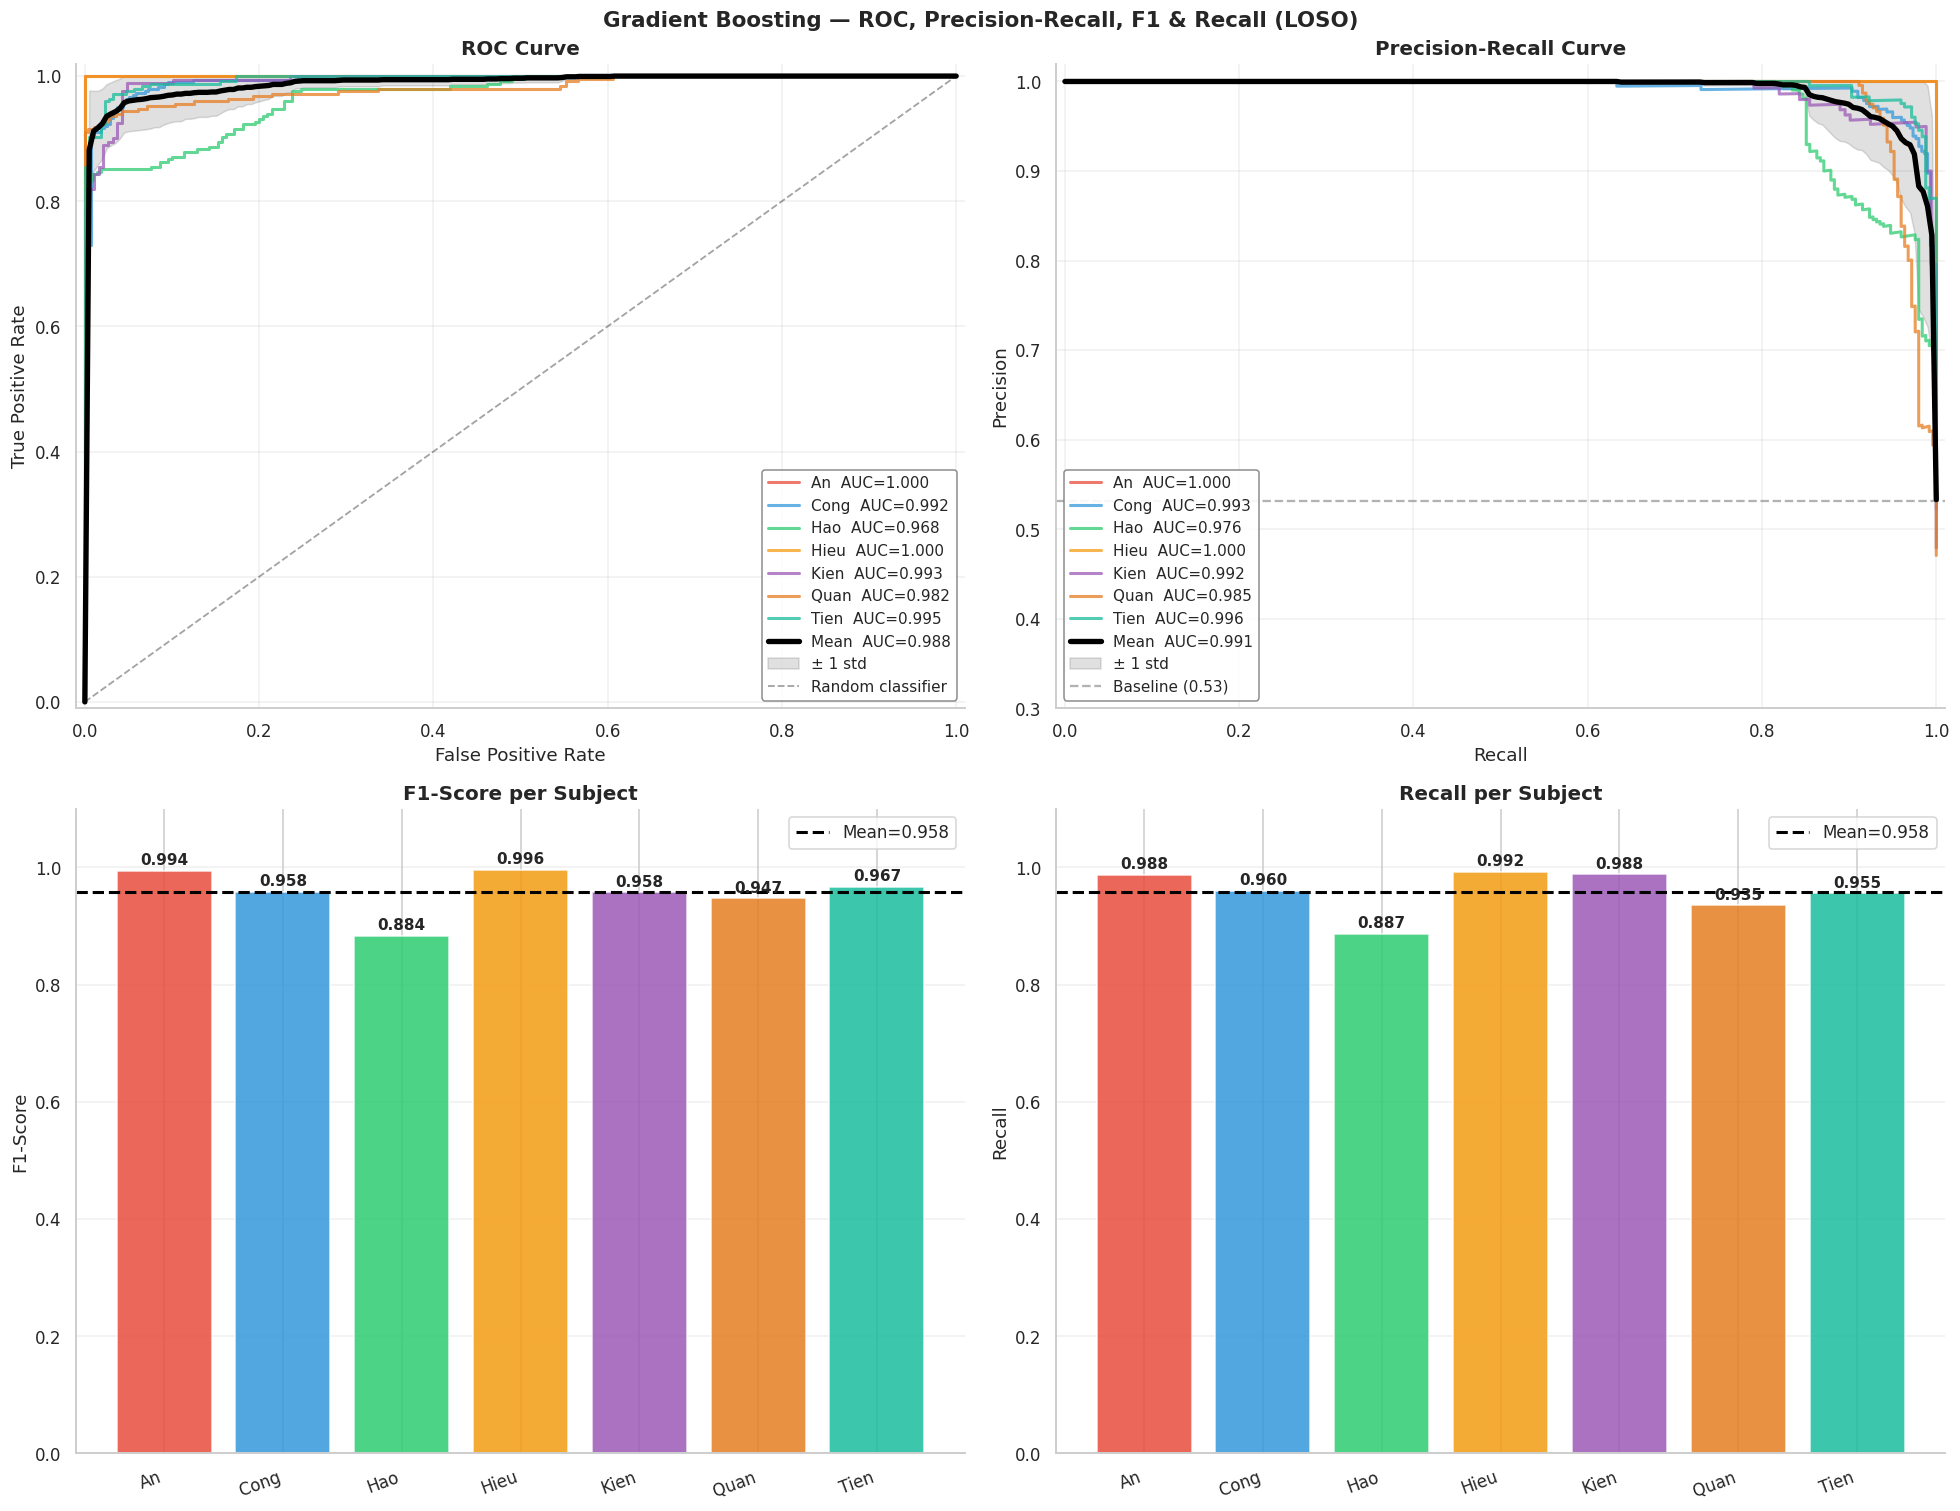

✅ Saved: curves_gb.png


In [ ]:
# ============================================================
# CELL 9: ROC CURVE & PRECISION-RECALL CURVE & F1/RECALL BAR
# ============================================================
from sklearn.metrics import roc_curve, auc

COLORS  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22', '#1abc9c']
MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

for model_name, label in [('RF', 'Random Forest'), ('GB', 'Gradient Boosting')]:

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    ax_roc = axes[0][0]
    ax_pr  = axes[0][1]
    ax_f1  = axes[1][0]
    ax_rec = axes[1][1]

    fig.suptitle(f'{label} — ROC, Precision-Recall, F1 & Recall (LOSO)',
                 fontsize=14, fontweight='bold')

    mean_fpr    = np.linspace(0, 1, 200)
    mean_recall = np.linspace(0, 1, 200)
    tpr_list    = []
    prec_list   = []

    f1_per_fold  = []
    rec_per_fold = []
    persons_list = []

    for fold, test_person in enumerate(unique_persons):
        test_mask = (persons == test_person)
        y_true    = y_raw[test_mask]
        proba     = results[model_name]['proba'][fold]

        # ── ROC ──────────────────────────────────────────────
        fpr, tpr, _ = roc_curve(y_true, proba)
        roc_auc_val = auc(fpr, tpr)
        tpr_interp  = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tpr_list.append(tpr_interp)

        ax_roc.plot(fpr, tpr,
                    color=COLORS[fold], linewidth=2.0, alpha=0.75,
                    linestyle='-',
                    label=f'{test_person}  AUC={roc_auc_val:.3f}')

        # ── PR ───────────────────────────────────────────────
        prec, rec, _ = precision_recall_curve(y_true, proba)
        pr_auc_val   = auc(rec[::-1], prec[::-1])
        prec_interp  = np.interp(mean_recall, rec[::-1], prec[::-1])
        prec_list.append(prec_interp)

        ax_pr.plot(rec, prec,
                   color=COLORS[fold], linewidth=2.0, alpha=0.75,
                   label=f'{test_person}  AUC={pr_auc_val:.3f}')

        # ── F1 & Recall tại threshold tối ưu ─────────────────
        r = results[model_name]
        f1_per_fold.append(r['f1'][fold])
        rec_per_fold.append(r['rec'][fold])
        persons_list.append(test_person)

    # ── Mean ROC ─────────────────────────────────────────────
    mean_tpr     = np.mean(tpr_list, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc_roc = auc(mean_fpr, mean_tpr)
    std_tpr      = np.std(tpr_list, axis=0)

    ax_roc.plot(mean_fpr, mean_tpr,
                color='black', linewidth=3.5, zorder=5,
                label=f'Mean  AUC={mean_auc_roc:.3f}')
    ax_roc.fill_between(mean_fpr,
                        np.clip(mean_tpr - std_tpr, 0, 1),
                        np.clip(mean_tpr + std_tpr, 0, 1),
                        alpha=0.12, color='black', label='± 1 std')
    ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.2,
                alpha=0.4, label='Random classifier')

    ax_roc.set_xlim([-0.01, 1.01]); ax_roc.set_ylim([-0.01, 1.02])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate',  fontsize=12)
    ax_roc.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax_roc.legend(fontsize=10, loc='lower right', framealpha=0.9, edgecolor='gray')
    ax_roc.grid(True, alpha=0.3); sns.despine(ax=ax_roc)

    # ── Mean PR ──────────────────────────────────────────────
    mean_prec   = np.mean(prec_list, axis=0)
    std_prec    = np.std(prec_list, axis=0)
    mean_auc_pr = auc(mean_recall, mean_prec)
    baseline    = np.sum(y_raw == 1) / len(y_raw)

    ax_pr.plot(mean_recall, mean_prec,
               color='black', linewidth=3.5, zorder=5,
               label=f'Mean  AUC={mean_auc_pr:.3f}')
    ax_pr.fill_between(mean_recall,
                       np.clip(mean_prec - std_prec, 0, 1),
                       np.clip(mean_prec + std_prec, 0, 1),
                       alpha=0.12, color='black', label='± 1 std')
    ax_pr.axhline(baseline, color='gray', linestyle='--',
                  linewidth=1.5, alpha=0.6,
                  label=f'Baseline ({baseline:.2f})')

    ax_pr.set_xlim([-0.01, 1.01]); ax_pr.set_ylim([0.3, 1.02])
    ax_pr.set_xlabel('Recall',    fontsize=12)
    ax_pr.set_ylabel('Precision', fontsize=12)
    ax_pr.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax_pr.legend(fontsize=10, loc='lower left', framealpha=0.9, edgecolor='gray')
    ax_pr.grid(True, alpha=0.3); sns.despine(ax=ax_pr)

    # ── F1 per Subject ───────────────────────────────────────
    x_pos = np.arange(len(persons_list))
    mean_f1 = np.mean(f1_per_fold)

    bars = ax_f1.bar(x_pos, f1_per_fold, color=COLORS[:len(persons_list)], alpha=0.85)
    ax_f1.axhline(mean_f1, color='black', linestyle='--', linewidth=2,
                  label=f'Mean={mean_f1:.3f}')
    for bar, val in zip(bars, f1_per_fold):
        ax_f1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax_f1.set_xticks(x_pos)
    ax_f1.set_xticklabels(persons_list, rotation=20, ha='right', fontsize=11)
    ax_f1.set_ylim([0, 1.1])
    ax_f1.set_ylabel('F1-Score', fontsize=12)
    ax_f1.set_title('F1-Score per Subject', fontsize=13, fontweight='bold')
    ax_f1.legend(fontsize=11); sns.despine(ax=ax_f1)
    ax_f1.grid(axis='y', alpha=0.3)

    # ── Recall per Subject ───────────────────────────────────
    mean_rec = np.mean(rec_per_fold)

    bars = ax_rec.bar(x_pos, rec_per_fold, color=COLORS[:len(persons_list)], alpha=0.85)
    ax_rec.axhline(mean_rec, color='black', linestyle='--', linewidth=2,
                   label=f'Mean={mean_rec:.3f}')
    for bar, val in zip(bars, rec_per_fold):
        ax_rec.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax_rec.set_xticks(x_pos)
    ax_rec.set_xticklabels(persons_list, rotation=20, ha='right', fontsize=11)
    ax_rec.set_ylim([0, 1.1])
    ax_rec.set_ylabel('Recall', fontsize=12)
    ax_rec.set_title('Recall per Subject', fontsize=13, fontweight='bold')
    ax_rec.legend(fontsize=11); sns.despine(ax=ax_rec)
    ax_rec.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'curves_{model_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: curves_{model_name.lower()}.png')

In [ ]:
# ============================================================
# CELL 7: TRAIN FINAL MODEL + SAVE
# ============================================================
print('Training final models trên toàn bộ data...')

scaler_final = StandardScaler()
X_all_s      = scaler_final.fit_transform(X_raw)

# ── Train cả 2 model ─────────────────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
gb_final = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=2, random_state=SEED
)

rf_final.fit(X_all_s, y_raw)
print('✅ Random Forest trained')
gb_final.fit(X_all_s, y_raw)
print('✅ Gradient Boosting trained')

# ── Save ─────────────────────────────────────────────────────
rf_path     = OUTPUT_DIR / 'final_rf_model.joblib'
gb_path     = OUTPUT_DIR / 'final_gb_model.joblib'
scaler_path = OUTPUT_DIR / 'scaler_final.pkl'
config_path = OUTPUT_DIR / 'config_feature_based.json'

joblib.dump(rf_final,    rf_path)
joblib.dump(gb_final,    gb_path)
joblib.dump(scaler_final, scaler_path)

config = {
    'approach'          : 'feature_based',
    'models'            : ['Random Forest', 'Gradient Boosting'],
    'n_features'        : int(X_raw.shape[1]),
    'feature_names'     : FEATURE_NAMES,
    'window_size'       : WINDOW_SIZE,
    'sample_rate'       : SAMPLE_RATE,
    'overlap_ratio'     : OVERLAP_RATIO,
    'n_hot_windows'     : N_HOT_WINDOWS,
    'exclude_subfolders': EXCLUDE_SUBFOLDERS,
    'class_names'       : CLASS_NAMES,
    'loso_results': {
        'RF': {
            'f1'    : round(float(np.mean(results['RF']['f1'])),  4),
            'recall': round(float(np.mean(results['RF']['rec'])), 4),
            'prec'  : round(float(np.mean(results['RF']['prec'])),4),
            'auc'   : round(float(np.mean(results['RF']['auc'])), 4),
            'false_alarm_rate'   : round(sum(results['RF']['fp']) /
                                   (sum(results['RF']['fp']) +
                                    sum(results['RF']['tn'])) * 100, 2),
            'miss_detection_rate': round(sum(results['RF']['fn']) /
                                   (sum(results['RF']['fn']) +
                                    sum(results['RF']['tp'])) * 100, 2),
        },
        'GB': {
            'f1'    : round(float(np.mean(results['GB']['f1'])),  4),
            'recall': round(float(np.mean(results['GB']['rec'])), 4),
            'prec'  : round(float(np.mean(results['GB']['prec'])),4),
            'auc'   : round(float(np.mean(results['GB']['auc'])), 4),
            'false_alarm_rate'   : round(sum(results['GB']['fp']) /
                                   (sum(results['GB']['fp']) +
                                    sum(results['GB']['tn'])) * 100, 2),
            'miss_detection_rate': round(sum(results['GB']['fn']) /
                                   (sum(results['GB']['fn']) +
                                    sum(results['GB']['tp'])) * 100, 2),
        },
    },
    'dataset': {
        'total_sessions': len(all_sessions),
        'total_windows' : int(len(X_raw)),
        'persons'       : list(np.unique(persons)),
    },
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'\n✅ RF model  : {rf_path}')
print(f'✅ GB model  : {gb_path}')
print(f'✅ Scaler    : {scaler_path}')
print(f'✅ Config    : {config_path}')

print(f'\n── LOSO Summary (sau khi fix leak) ─────────────────────')
print(f'{"":10} {"F1":>8} {"Recall":>8} {"FAR%":>8} {"MDR%":>8}')
print('─' * 42)
for mn in ['RF', 'GB']:
    r    = results[mn]
    far  = sum(r['fp']) / (sum(r['fp']) + sum(r['tn'])) * 100
    mdr  = sum(r['fn']) / (sum(r['fn']) + sum(r['tp'])) * 100
    print(f'{mn:10} {np.mean(r["f1"]):>8.4f} {np.mean(r["rec"]):>8.4f} '
          f'{far:>8.2f} {mdr:>8.2f}')

Training final models trên toàn bộ data...
✅ Random Forest trained
✅ Gradient Boosting trained

✅ RF model  : /content/drive/MyDrive/data_pbl5/models_7_pers_feature/final_rf_model.joblib
✅ GB model  : /content/drive/MyDrive/data_pbl5/models_7_pers_feature/final_gb_model.joblib
✅ Scaler    : /content/drive/MyDrive/data_pbl5/models_7_pers_feature/scaler_final.pkl
✅ Config    : /content/drive/MyDrive/data_pbl5/models_7_pers_feature/config_feature_based.json

── LOSO Summary (sau khi fix leak) ─────────────────────
                 F1   Recall     FAR%     MDR%
──────────────────────────────────────────
RF           0.9625   0.9620     4.04     3.86
GB           0.9577   0.9580     4.71     4.32
